# Exercise 1 - Model Training and Evaluation

## a) Extracting TF-IDF features

Requirements:
- maximum numbers of terms set to 5000
- add idf smoothing for out-of-vocabulary words
- minimum number of documents a term must appear in as min_df=10
- maximum proportion of documents a term can appear in as max_df=0.9

In [19]:
# loading the dataset

import pandas as pd

# paths
train_csv = "train.csv"
val_csv   = "val.csv"
test_csv  = "test.csv"

# load; all of them have 2 columns: Text, Label
train = pd.read_csv(train_csv)
val   = pd.read_csv(val_csv)
test  = pd.read_csv(test_csv)

print("Train:", train.shape, "Val:", val.shape, "Test:", test.shape)

Train: (50587, 2) Val: (6324, 2) Test: (6324, 2)


In [ ]:
# cleaning the dataset - lowercases and removes extra whitespaces in every text
import re

def simple_clean(text):
    if pd.isna(text):
        return ""
    text = str(text).lower().strip() # lowercasing and strip
    return re.sub(r'[^\w\s]', '', text) #remove punctuation

train['text_clean'] = train['Text'].apply(simple_clean)
val['text_clean']   = val['Text'].apply(simple_clean)
test['text_clean']  = test['Text'].apply(simple_clean)

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF vectorizer with requested params
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=10,
    max_df=0.9,
    smooth_idf=True,   # idf smoothing
    strip_accents='unicode', # for characters like ç, ã, etc
)

In [12]:
# fit on training texts and transform all splits

X_train = tfidf.fit_transform(train['text_clean'])
X_val   = tfidf.transform(val['text_clean'])
X_test  = tfidf.transform(test['text_clean'])

y_train = train['Label'].astype(int).values
y_val   = val['Label'].astype(int).values
y_test  = test['Label'].astype(int).values

print("TF-IDF shapes:", X_train.shape, X_val.shape, X_test.shape)

import joblib
joblib.dump(tfidf, "artifacts/tfidf_vectorizer.joblib") #saving vectorization

TF-IDF shapes: (50587, 5000) (6324, 5000) (6324, 5000)


['artifacts/tfidf_vectorizer.joblib']

## b) Training models

Requirements:
- use 5-fold cross-validation
- tune key hyperparameters systematically (e.g., regularization strength λ, tree depth)
- document your hyperparameter search process

Models to use:
- Decision Tree
- Gaussian Naive Bayes
- Logistic Regression with L2 regularization
- Logistic Regression with L1 regularization
- Multi-Layer Perceptron (MLP) - You are free to choose your architecture but up to 2 hidden layers.

### Global Stuff

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import joblib
import os

# dir to save all models
os.makedirs("artifacts/models", exist_ok=True)

# cross validation 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def run_grid_search(model, param_grid, X, y, model_name):
    print(f"Running GridSearchCV for {model_name}...")
    
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )
    grid.fit(X, y)

    # results file paths
    results_path = f"artifacts/models/{model_name}_cv_results.csv"
    best_model_path = f"artifacts/models/{model_name}_best.joblib"

    # save CV results
    new_results_df = pd.DataFrame(grid.cv_results_)
    
    if os.path.exists(results_path):
        # not the first run, so append this run
        old_results_df = pd.read_csv(results_path)
        combined_df = pd.concat([old_results_df, new_results_df], ignore_index=True)
        combined_df.to_csv(results_path, index=False)
        
    else:
        #first run
        new_results_df.to_csv(results_path, index=False)

    # save best model only if it's better than the existing one
    save_model = True
    if os.path.exists(best_model_path):
        try:
            existing_model = joblib.load(best_model_path)
            
            # we need to get its score on the current data
            from sklearn.metrics import f1_score
            existing_score = f1_score(y, existing_model.predict(X), average='macro')
            
            if existing_score >= grid.best_score_:
                # the old model is better, so we don't save
                save_model = False
                
        except Exception as e:
            print("Warning: couldn't evaluate existing model. Overwriting.")
            save_model = True

    if save_model:
        joblib.dump(grid.best_estimator_, best_model_path)
        print(f"Saved new best model for {model_name}.")
        
    else:
        print(f"Existing best model for {model_name} is better. Not overwritten.")

    print(f"Best params for {model_name}: {grid.best_params_}")
    print(f"Best CV F1-macro: {grid.best_score_:.4f}")

    return grid.best_estimator_

### Decision Tree

In [15]:
from sklearn.tree import DecisionTreeClassifier

dt_params = {
    'max_depth': [10, 20, 50, None],
    'min_samples_split': [2, 5, 10]
}

best_dt = run_grid_search(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    X_train,
    y_train,
    "decision_tree"
)


Running GridSearchCV for decision_tree...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Existing best model for decision_tree is better. Not overwritten.
Best params for decision_tree: {'max_depth': 50, 'min_samples_split': 2}
Best CV F1-macro: 0.8353


### Gaussian Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

X_train_dense = X_train.toarray() # since GaussianNB requires dense input and TF-IDF is sparse, we convert using .toarray()

gnb_params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

best_gnb = run_grid_search(
    GaussianNB(),
    gnb_params,
    X_train_dense,
    y_train,
    "gaussian_nb"
)


Running GridSearchCV for gaussian_nb...
Fitting 5 folds for each of 4 candidates, totalling 20 fits


c:\Users\Administrador\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
5 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Administrador\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Administrador\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File 

Saved new best model for gaussian_nb.
Best params for gaussian_nb: {'var_smoothing': 1e-08}
Best CV F1-macro: 0.8487


### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression


In [ ]:
# with L2 regularization 
lr_l2_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l2']
}

best_lr_l2 = run_grid_search(
    LogisticRegression(max_iter=5000, n_jobs=-1),
    lr_l2_params,
    X_train,
    y_train,
    "logreg_l2"
)

Running GridSearchCV for logreg_l2...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\Administrador\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 12.
  warnings.warn(


Existing best model for logreg_l2 is better. Not overwritten.
Best params for logreg_l2: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1-macro: 0.9036


In [ ]:
# with L1 regularization
lr_l1_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1']
}

best_lr_l1 = run_grid_search(
    LogisticRegression(max_iter=5000, n_jobs=-1),
    lr_l1_params,
    X_train,
    y_train,
    "logreg_l1"
)

Running GridSearchCV for logreg_l1...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Existing best model for logreg_l1 is better. Not overwritten.
Best params for logreg_l1: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
Best CV F1-macro: 0.8997


### Multi-Layer Perceptron

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_params = {
    'hidden_layer_sizes': [(128,), (256,), (128, 64), (256, 128)],
    'alpha': [1e-4, 1e-3, 1e-2],
    'learning_rate_init': [1e-3, 1e-4]
}

best_mlp = run_grid_search(
    MLPClassifier(max_iter=50, random_state=42),  # early stopping happens automatically
    mlp_params,
    X_train,
    y_train,
    "mlp"
)


Running GridSearchCV for mlp...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Saved new best model for mlp.
Best params for mlp: {'alpha': 0.01, 'hidden_layer_sizes': (256, 128), 'learning_rate_init': 0.001}
Best CV F1-macro: 0.9194


### Evaluation

In [ ]:
from sklearn.metrics import classification_report, f1_score

def evaluate_model(model, X, y, name):
    y_pred = model.predict(X)
    f1 = f1_score(y, y_pred, average='macro')
    print(f"\n{name} – Validation F1-macro: {f1:.4f}")
    print(classification_report(y, y_pred))
    return f1

X_val_dense = X_val.toarray() # same as before; since GaussianNB requires dense input and TF-IDF is sparse, we convert using .toarray()

val_results = {
    "DecisionTree": evaluate_model(best_dt, X_val, y_val, "Decision Tree"),
    "GaussianNB": evaluate_model(best_gnb, X_val_dense, y_val, "GaussianNB"),
    "LR_L2": evaluate_model(best_lr_l2, X_val, y_val, "LR L2"),
    "LR_L1": evaluate_model(best_lr_l1, X_val, y_val, "LR L1"),
    "MLP": evaluate_model(best_mlp, X_val, y_val, "MLP")
}

print("\nValidation F1 results summary:")
print(val_results)



Decision Tree – Validation F1-macro: 0.8432
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      3141
           1       0.86      0.82      0.84      3183

    accuracy                           0.84      6324
   macro avg       0.84      0.84      0.84      6324
weighted avg       0.84      0.84      0.84      6324


GaussianNB – Validation F1-macro: 0.8516
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      3141
           1       0.85      0.86      0.85      3183

    accuracy                           0.85      6324
   macro avg       0.85      0.85      0.85      6324
weighted avg       0.85      0.85      0.85      6324


LR L2 – Validation F1-macro: 0.9075
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      3141
           1       0.91      0.91      0.91      3183

    accuracy                           0.91      6324
   m

## c) Comparison table

### Based on test metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def evaluate_test(model, X, y):
    """Compute test metrics for the comparison table."""
    y_pred = model.predict(X)
    return {
        "accuracy": accuracy_score(y, y_pred),
        "precision_macro": precision_score(y, y_pred, average="macro"),
        "recall_macro": recall_score(y, y_pred, average="macro"),
        "f1_macro": f1_score(y, y_pred, average="macro")
    }

X_test_dense = X_test.toarray() # dense version for GNB

# evaluate all models on test set
test_results = {
    "DecisionTree": evaluate_test(best_dt, X_test, y_test),
    "GaussianNB": evaluate_test(best_gnb, X_test_dense, y_test),
    "LR_L2": evaluate_test(best_lr_l2, X_test, y_test),
    "LR_L1": evaluate_test(best_lr_l1, X_test, y_test),
    "MLP": evaluate_test(best_mlp, X_test, y_test)
}

# build comparison table
df_test = pd.DataFrame(test_results).T
print("\n=== Test Set Comparison Table ===")
display(df_test)


=== Test Set Comparison Table ===


,accuracy,precision_macro,recall_macro,f1_macro
DecisionTree,0.844086,0.844152,0.844071,0.844074
GaussianNB,0.853732,0.853790,0.853746,0.853729
LR_L2,0.904649,0.904658,0.904644,0.904647
LR_L1,0.901803,0.901809,0.901798,0.901801
MLP,0.923782,0.923828,0.923795,0.923781


In [ ]:
# select best model (based on F1-macro)
best_model_name = df_test["f1_macro"].idxmax()
print("\nBest model based on Test F1-macro:", best_model_name)

# retrieve actual model
best_model = {
    "DecisionTree": best_dt,
    "GaussianNB": best_gnb,
    "LR_L2": best_lr_l2,
    "LR_L1": best_lr_l1,
    "MLP": best_mlp
}[best_model_name]

best_X_test = X_test_dense if best_model_name == "GaussianNB" else X_test


Best model based on Test F1-macro: MLP


### ROC Curve + Macro-Averaged AUC

Unique labels: [0 1]
Number of classes: 2
y_score shape: (6324,)


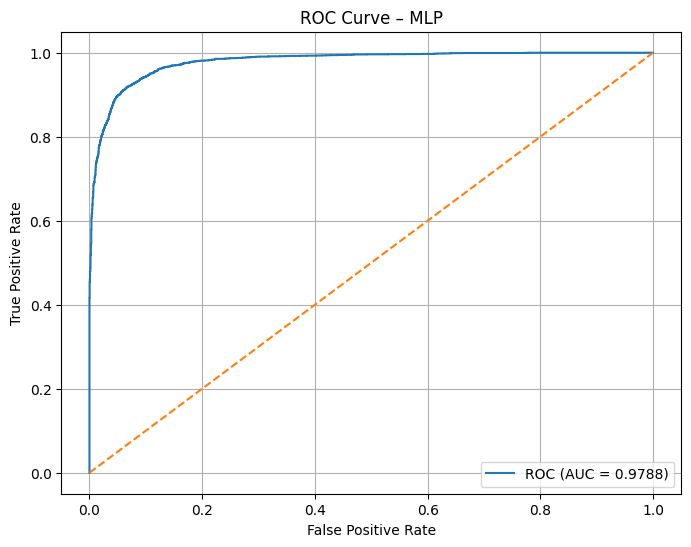


AUC: 0.9788322792264003


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# identify unique classes
classes = np.unique(y_test)

print("Unique labels:", classes)
print("Number of classes:", len(classes))

# probability scores (P(y=1))
if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(best_X_test)[:, 1] # positive class only
else:
    y_score = best_model.decision_function(best_X_test)
    # if decision_function returns shape (N,), no slicing needed

print("y_score shape:", y_score.shape)

# compute ROC curve for the positive class
fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=1)

# compute AUC
roc_auc = auc(fpr, tpr)

# plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title(f"ROC Curve – {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

print("\nAUC:", roc_auc)
